In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn streamlit

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.2 MB/s eta 0:00:32
    --------------------------------------- 1.8/101.7 MB 4.9 MB/s eta 0:00:21
   - -------------------------------------- 3.4/101.7 MB 5.8 MB/s eta 0:00:17
   - -------------------------------------- 4.7/101.7 MB 6.3 MB/s eta 0:00:16
   -- ------------------------------------- 6.3/101.7 MB 6.5 MB/s eta 0:00:15
   --- ------------------------------------ 7.9/101.7 MB 6.7 MB/s eta 0:00:15
   --- ------------------------------------ 9.4/101.7 MB 6.8 MB/s eta 0:00:14
   ---- ----------------------------------- 11.0/101.7 MB 6.8 MB/s eta 0:00:14
   ---- ----------------------------------- 11.5/101.7 MB 6.7 MB/s eta 0:00:14
   ---- ----------------------------------- 11.5/101.7 MB 6.7 MB/s eta 0:00:14
   ---- ----------------------------------- 11.5/101.7 MB 6.7 MB/s eta 0:00:14
   ---- ----------------------------------- 11.5/101.7 MB 6.7 MB/s 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:

df = pd.read_csv('diabetes.csv')

# we show the first 5 rows
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Statistical summary of every column
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
# These columns cannot biologically be zero, impossible
# We check how many zeros exist in each
cols_with_fake_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("🔍 Fake zero count per column:")
print("=" * 45)

for col in cols_with_fake_zeros:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df) * 100).round(1)
    print(f"  {col:<20} {zero_count:>3} zeros  ({zero_pct}%)")

🔍 Fake zero count per column:
  Glucose                5 zeros  (0.7%)
  BloodPressure         35 zeros  (4.6%)
  SkinThickness        227 zeros  (29.6%)
  Insulin              374 zeros  (48.7%)
  BMI                   11 zeros  (1.4%)


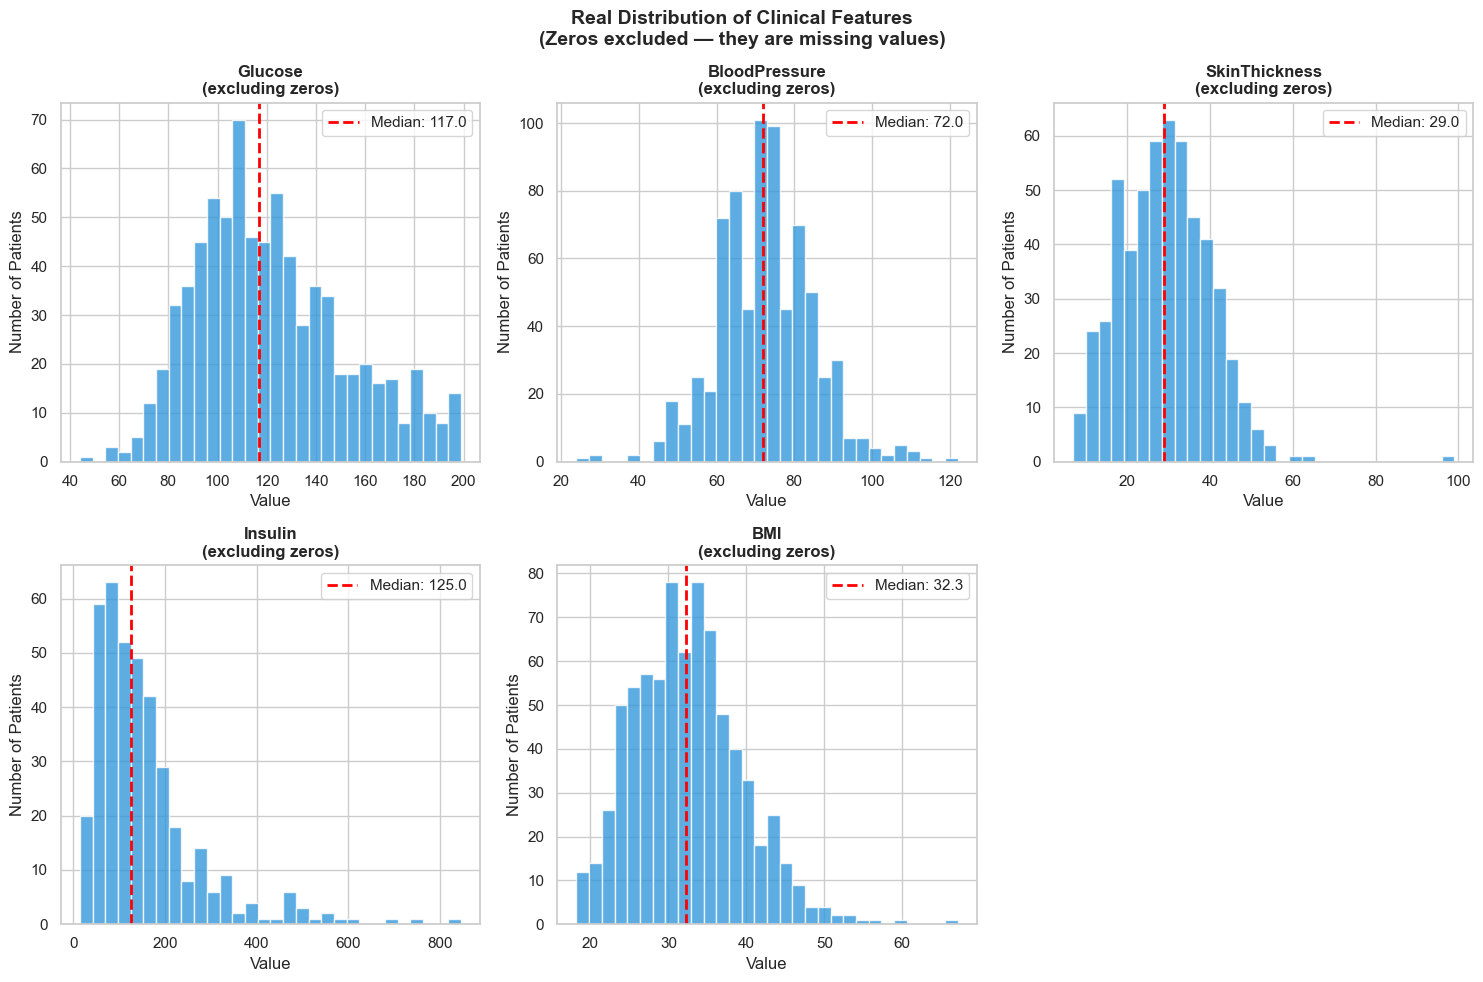

✅ Chart saved as distributions.png


In [6]:
# Visualize the distribution of each problematic column
# This helps to understand the data BEFORE we change anything

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Convert 2D array of axes into 1D for easy looping

cols_to_plot = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for i, col in enumerate(cols_to_plot):
    # Plot only non-zero values to see the real distribution
    non_zero = df[df[col] != 0][col]
    axes[i].hist(non_zero, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\n(excluding zeros)', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Number of Patients')
    axes[i].axvline(non_zero.median(), color='red', linestyle='--', 
                    linewidth=2, label=f'Median: {non_zero.median():.1f}')
    axes[i].legend()

# Hide the 6th subplot (we only have 5 columns)
axes[5].set_visible(False)

plt.suptitle('Real Distribution of Clinical Features\n(Zeros excluded — they are missing values)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved as distributions.png")

In [7]:
# Compare medians between diabetic and non-diabetic patients
# This proves WHY we must impute grouped by Outcome

print("📊 Median values by Outcome (0=Healthy, 1=Diabetic)")
print("=" * 55)

cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_check:
    # Filter out zeros first — we want real measurements only
    real_data = df[df[col] != 0]
    
    median_healthy  = real_data[real_data['Outcome'] == 0][col].median()
    median_diabetic = real_data[real_data['Outcome'] == 1][col].median()
    difference = round(median_diabetic - median_healthy, 1)
    
    print(f"  {col:<20} Healthy: {median_healthy:>6.1f}   Diabetic: {median_diabetic:>6.1f}   Diff: +{difference}")

📊 Median values by Outcome (0=Healthy, 1=Diabetic)
  Glucose              Healthy:  107.0   Diabetic:  140.0   Diff: +33.0
  BloodPressure        Healthy:   70.0   Diabetic:   74.5   Diff: +4.5
  SkinThickness        Healthy:   27.0   Diabetic:   32.0   Diff: +5.0
  Insulin              Healthy:  102.5   Diabetic:  169.5   Diff: +67.0
  BMI                  Healthy:   30.1   Diabetic:   34.3   Diff: +4.2


In [9]:
# Work on a clean copy of original data
df_clean = df.copy()

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Convert all these columns to float FIRST
# float64 = numbers that can have decimals (74.5, 102.5 etc)
# int64   = whole numbers only (74, 102 etc)
# We convert to float so pandas doesn't complain when we insert decimal medians
df_clean[cols_to_fix] = df_clean[cols_to_fix].astype(float)

for col in cols_to_fix:
    # Get median for each outcome group, excluding fake zeros
    median_by_group = df_clean[df_clean[col] != 0].groupby('Outcome')[col].median()
    
    # Replace zeros with the correct group median
    for outcome_value in [0, 1]:
        mask = (df_clean[col] == 0) & (df_clean['Outcome'] == outcome_value)
        df_clean.loc[mask, col] = median_by_group[outcome_value]

print("✅ Imputation complete — no warnings this time!")
print()

# Verify all zeros are gone
print("🔍 Zero count after imputation:")
print("=" * 40)
for col in cols_to_fix:
    zeros_remaining = (df_clean[col] == 0).sum()
    print(f"  {col:<20} {zeros_remaining} zeros remaining")

print()

# Also verify the data types are now float
print("📋 Column data types after conversion:")
print(df_clean[cols_to_fix].dtypes)

✅ Imputation complete — no warnings this time!

🔍 Zero count after imputation:
  Glucose              0 zeros remaining
  BloodPressure        0 zeros remaining
  SkinThickness        0 zeros remaining
  Insulin              0 zeros remaining
  BMI                  0 zeros remaining

📋 Column data types after conversion:
Glucose          float64
BloodPressure    float64
SkinThickness    float64
Insulin          float64
BMI              float64
dtype: object


📊 Class Distribution:
  Healthy  (0): 500 patients (65.1%)
  Diabetic (1): 268 patients (34.9%)

  Imbalance ratio: 1.9 healthy for every 1 diabetic


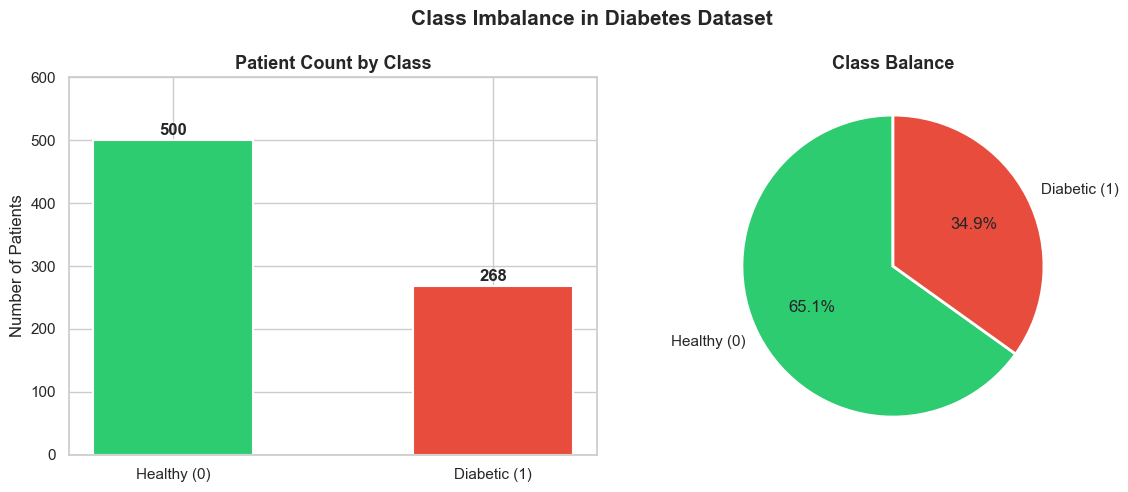

In [10]:
# Check how many healthy vs diabetic patients we have
print("📊 Class Distribution:")
print("=" * 35)

counts = df_clean['Outcome'].value_counts()
pct_healthy  = (counts[0] / len(df_clean) * 100).round(1)
pct_diabetic = (counts[1] / len(df_clean) * 100).round(1)

print(f"  Healthy  (0): {counts[0]} patients ({pct_healthy}%)")
print(f"  Diabetic (1): {counts[1]} patients ({pct_diabetic}%)")
print()
print(f"  Imbalance ratio: {(counts[0]/counts[1]):.1f} healthy for every 1 diabetic")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Healthy (0)', 'Diabetic (1)'], 
                    counts.values, 
                    color=colors, 
                    edgecolor='white', 
                    linewidth=1.5,
                    width=0.5)

# Add number labels on top of each bar
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 8,
                 str(count), 
                 ha='center', 
                 fontweight='bold', 
                 fontsize=12)

axes[0].set_title('Patient Count by Class', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, 600)

# Pie chart
axes[1].pie(counts.values,
            labels=['Healthy (0)', 'Diabetic (1)'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontweight='bold', fontsize=13)

plt.suptitle('Class Imbalance in Diabetes Dataset', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features (X) from target (y)
# X = everything the model uses to make predictions (the clinical measurements)
# y = what we're trying to predict (diabetes yes or no)
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f"X shape: {X.shape}  ← 768 patients, 8 features")
print(f"y shape: {y.shape}  ← 768 labels (0 or 1)")
print(f"\nFeature columns: {list(X.columns)}")

X shape: (768, 8)  ← 768 patients, 8 features
y shape: (768,)  ← 768 labels (0 or 1)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [12]:
# STEP 1: Split data first
# 80% of patients go to training, 20% go to testing
# The model learns from training data and is evaluated on test data
# Test data simulates real-world new patients the model has never seen

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% for testing
    random_state=42,      # Makes the split reproducible — same result every time
    stratify=y            # Maintains the 65/35 ratio in BOTH splits
)

print("✅ Data split complete")
print(f"\n  Training set: {X_train.shape[0]} patients")
print(f"  Test set:     {X_test.shape[0]} patients")
print()
print(f"  Training class balance:")
print(f"    Healthy:  {(y_train == 0).sum()} patients")
print(f"    Diabetic: {(y_train == 1).sum()} patients")
print()
print(f"  Test class balance:")
print(f"    Healthy:  {(y_test == 0).sum()} patients")
print(f"    Diabetic: {(y_test == 1).sum()} patients")

✅ Data split complete

  Training set: 614 patients
  Test set:     154 patients

  Training class balance:
    Healthy:  400 patients
    Diabetic: 214 patients

  Test class balance:
    Healthy:  100 patients
    Diabetic: 54 patients


Before SMOTE:
  Training healthy:  400
  Training diabetic: 214

After SMOTE:
  Training healthy:  400
  Training diabetic: 400



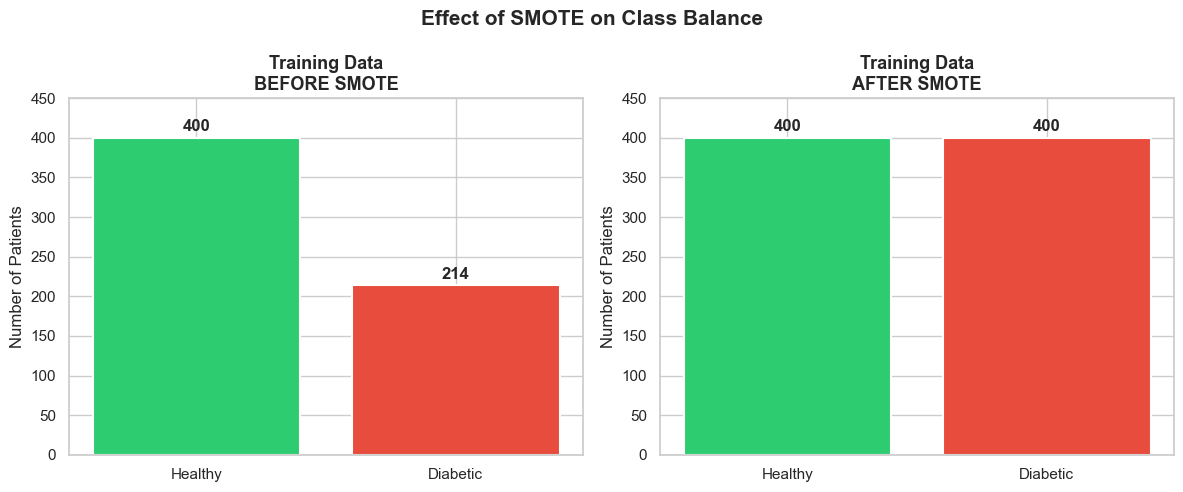

✅ SMOTE applied — test data untouched and still 100% real patients


In [13]:
# STEP 2: Apply SMOTE only to training data
# We want the model to learn from balanced data
# But test data must stay real, no synthetic patients in evaluation

print("Before SMOTE:")
print(f"  Training healthy:  {(y_train == 0).sum()}")
print(f"  Training diabetic: {(y_train == 1).sum()}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Training healthy:  {(y_train_balanced == 0).sum()}")
print(f"  Training diabetic: {(y_train_balanced == 1).sum()}")
print()

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
before_counts = [( y_train == 0).sum(), (y_train == 1).sum()]
axes[0].bar(['Healthy', 'Diabetic'], before_counts, 
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Training Data\nBEFORE SMOTE', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, 450)
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=12)

# After SMOTE
after_counts = [(y_train_balanced == 0).sum(), (y_train_balanced == 1).sum()]
axes[1].bar(['Healthy', 'Diabetic'], after_counts,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Training Data\nAFTER SMOTE', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Patients')
axes[1].set_ylim(0, 450)
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Effect of SMOTE on Class Balance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SMOTE applied — test data untouched and still 100% real patients")

In [14]:
from sklearn.preprocessing import StandardScaler

# Scale the features
# XGBoost doesn't need scaling but it help training stability
# and is REQUIRED for fair SHAP value comparison later
# We fit the scaler on training data only

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling complete")
print()
print("What StandardScaler does:")
print("  Takes each feature and transforms it so that:")
print("  → Mean (average) becomes 0")
print("  → Standard deviation becomes 1")
print()
print("Example:")
print(f"  Glucose before scaling — Mean: {X_train_balanced['Glucose'].mean():.1f}, "
      f"Std: {X_train_balanced['Glucose'].std():.1f}")

# Convert to DataFrame to check
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_balanced.columns)
print(f"  Glucose after scaling  — Mean: {X_train_scaled_df['Glucose'].mean():.4f}, "
      f"Std: {X_train_scaled_df['Glucose'].std():.4f}")

✅ Scaling complete

What StandardScaler does:
  Takes each feature and transforms it so that:
  → Mean (average) becomes 0
  → Standard deviation becomes 1

Example:
  Glucose before scaling — Mean: 126.1, Std: 30.7
  Glucose after scaling  — Mean: 0.0000, Std: 1.0006


In [15]:
from xgboost import XGBClassifier

# Create the XGBoost model
# These are called HYPERPARAMETERS — settings we choose before training


xgb_model = XGBClassifier(
    n_estimators=200,        # How many trees to build (200 doctors voting)
    max_depth=4,             # How many questions each tree can ask
    learning_rate=0.1,       # How much each tree corrects the previous one
    subsample=0.8,           # Each tree sees 80% of training data randomly
    colsample_bytree=0.8,    # Each tree sees 80% of features randomly
    random_state=42,
    eval_metric='logloss',   # How we measure error during training
    verbosity=0              # Suppress training messages
)

# Train the model
# The model goes through all 800 balanced training patients
# and builds 200 trees sequentially
xgb_model.fit(X_train_scaled, y_train_balanced)

print("✅ XGBoost model trained successfully")
print()
print(f"  Trees built:    {xgb_model.n_estimators}")
print(f"  Max tree depth: {xgb_model.max_depth}")
print(f"  Learning rate:  {xgb_model.learning_rate}")
print()
print("The model has finished learning from the training data.")
print("Now we test it on the 154 real patients it has never seen.")

✅ XGBoost model trained successfully

  Trees built:    200
  Max tree depth: 4
  Learning rate:  0.1

The model has finished learning from the training data.
Now we test it on the 154 real patients it has never seen.


In [16]:
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score, 
    roc_curve, ConfusionMatrixDisplay
)

# Make predictions on test data
# predict()       → gives the final decision: 0 or 1
# predict_proba() → gives the probability: e.g. 0.73 chance of diabetes
y_pred      = xgb_model.predict(X_test_scaled)
y_prob      = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("       MODEL EVALUATION — 154 Real Patients")
print("=" * 50)
print()
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, 
      target_names=['Healthy (0)', 'Diabetic (1)']))

       MODEL EVALUATION — 154 Real Patients

  Accuracy:  0.8831
  ROC-AUC:   0.9504

              precision    recall  f1-score   support

 Healthy (0)       0.92      0.90      0.91       100
Diabetic (1)       0.82      0.85      0.84        54

    accuracy                           0.88       154
   macro avg       0.87      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



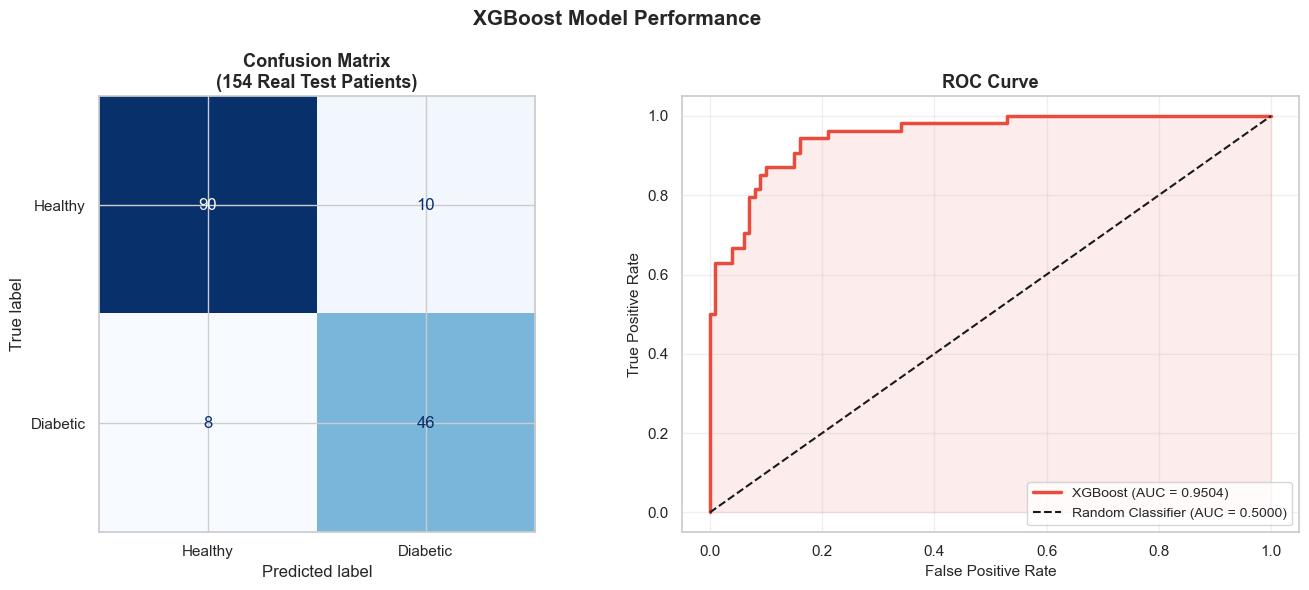

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === LEFT: Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Healthy', 'Diabetic'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(154 Real Test Patients)', 
                   fontweight='bold', fontsize=13)

# === RIGHT: ROC Curve ===
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'XGBoost (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, 
             label='Random Classifier (AUC = 0.5000)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('XGBoost Model Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix in Plain English:")
print("=" * 45)
print(f"  True Negatives  (TN): {tn} — Healthy, predicted Healthy")
print(f"  False Positives (FP): {fp} — Healthy, predicted Diabetic")
print(f"  False Negatives (FN): {fn} — Diabetic, predicted Healthy")
print(f"  True Positives  (TP): {tp} — Diabetic, predicted Diabetic")
print()
print(f"  Correctly identified: {tn + tp} out of {len(y_test)}")
print(f"  Diabetic patients missed: {fn} out of {tp + fn}")

Confusion Matrix in Plain English:
  True Negatives  (TN): 90 — Healthy, predicted Healthy
  False Positives (FP): 10 — Healthy, predicted Diabetic
  False Negatives (FN): 8 — Diabetic, predicted Healthy
  True Positives  (TP): 46 — Diabetic, predicted Diabetic

  Correctly identified: 136 out of 154
  Diabetic patients missed: 8 out of 54


In [22]:
import shap

# Create a SHAP explainer for our XGBoost model
# TreeExplainer is specifically optimised for tree-based models
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for ALL test patients
# This tells us why the model made each prediction
shap_values = explainer.shap_values(X_test_scaled)

# Convert test data back to DataFrame with column names
# (scaling converted it to a plain array — we need names for the charts)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("SHAP explainer created successfully")
print()
print(f"  SHAP values shape: {shap_values.shape}")
print(f"  This means: {shap_values.shape[0]} patients × {shap_values.shape[1]} features")
print()
print("  For each of the 154 test patients we now know")
print("  exactly how much each feature contributed to")
print("  their individual diabetes prediction.")

SHAP explainer created successfully

  SHAP values shape: (154, 8)
  This means: 154 patients × 8 features

  For each of the 154 test patients we now know
  exactly how much each feature contributed to
  their individual diabetes prediction.


CHART 1 — Global Feature Importance
Which features matter most overall?



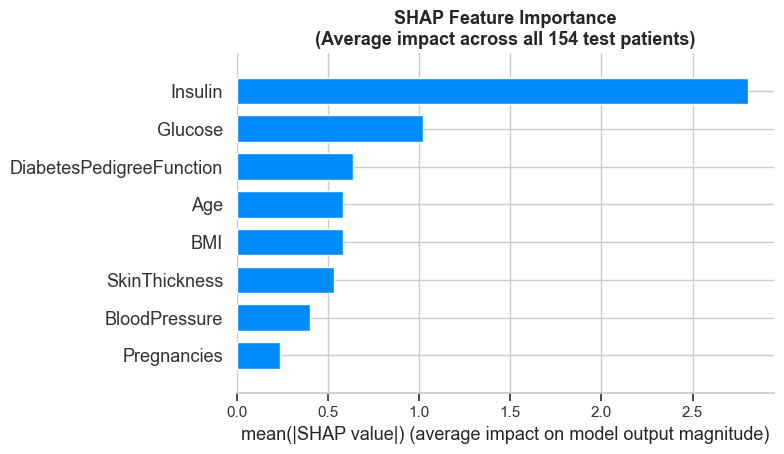

In [23]:
print("CHART 1 — Global Feature Importance")
print("Which features matter most overall?")
print()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test_df,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance\n(Average impact across all 154 test patients)', 
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

CHART 2 — Beeswarm Plot
How does each feature affect predictions and in which direction?



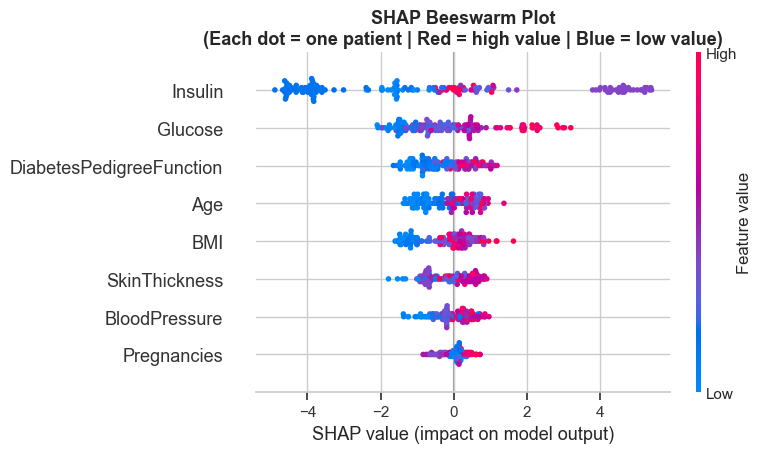

In [24]:
print("CHART 2 — Beeswarm Plot")
print("How does each feature affect predictions and in which direction?")
print()

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_df,
    show=False
)
plt.title('SHAP Beeswarm Plot\n(Each dot = one patient | Red = high value | Blue = low value)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

CHART 3 — Individual Patient Explanation
  Patient index:      3
  Actual outcome:     Diabetic
  Model prediction:   Diabetic
  Diabetes probability: 98.4%

  Clinical measurements:
  -----------------------------------
    Pregnancies                    7.0
    Glucose                        114.0
    BloodPressure                  64.0
    SkinThickness                  32.0
    Insulin                        169.5
    BMI                            27.4
    DiabetesPedigreeFunction       0.7
    Age                            34.0

  Waterfall chart below shows WHY the model
  assigned this probability to this patient:



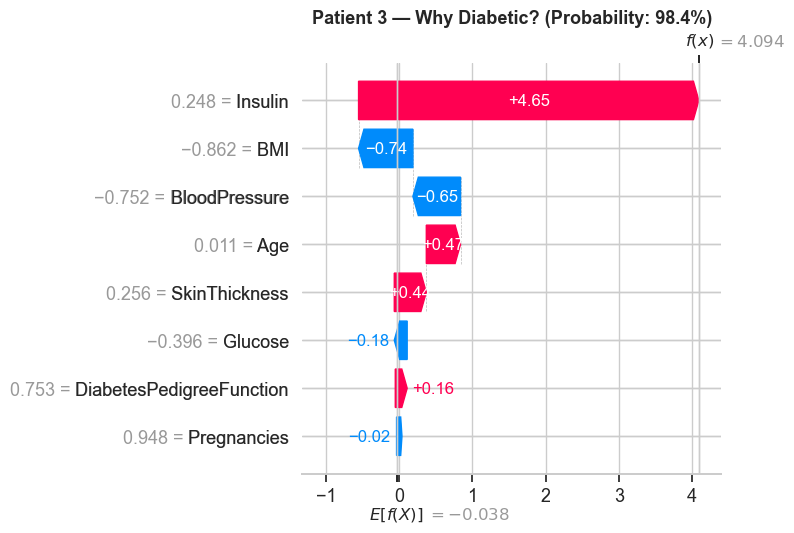

In [25]:
# Pick a diabetic patient the model correctly identified
# Find index of first True Positive — correctly predicted diabetic patient
tp_indices = np.where((y_pred == 1) & (y_test.values == 1))[0]
patient_idx = tp_indices[0]

print("CHART 3 — Individual Patient Explanation")
print("=" * 45)
print(f"  Patient index:      {patient_idx}")
print(f"  Actual outcome:     {'Diabetic' if y_test.values[patient_idx] == 1 else 'Healthy'}")
print(f"  Model prediction:   {'Diabetic' if y_pred[patient_idx] == 1 else 'Healthy'}")
print(f"  Diabetes probability: {y_prob[patient_idx]:.1%}")
print()

# Show their actual clinical values (unscaled — easier to interpret)
patient_real = X_test.iloc[patient_idx]
print("  Clinical measurements:")
print("  " + "-" * 35)
for feature, value in patient_real.items():
    print(f"    {feature:<30} {value:.1f}")

print()
print("  Waterfall chart below shows WHY the model")
print("  assigned this probability to this patient:")
print()

# Waterfall plot — shows each feature's contribution step by step
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[patient_idx],
        feature_names=X.columns.tolist()
    ),
    show=False
)
plt.title(f'Patient {patient_idx} — Why Diabetic? (Probability: {y_prob[patient_idx]:.1%})',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Cross validation gives a more honest estimate of real performance
# than a single train/test split
# We use StratifiedKFold to preserve class balance in each fold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross validation on the BALANCED training data
cv_scores = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train_balanced,
    cv=cv,
    scoring='roc_auc'
)

print("5-Fold Cross Validation Results:")
print("=" * 40)
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: ROC-AUC = {score:.4f}")
print()
print(f"  Mean ROC-AUC: {cv_scores.mean():.4f}")
print(f"  Std Dev:      {cv_scores.std():.4f}")
print()
print("Low standard deviation = consistent, reliable model")
print("Mean close to test AUC = no overfitting")

5-Fold Cross Validation Results:
  Fold 1: ROC-AUC = 0.9608
  Fold 2: ROC-AUC = 0.9558
  Fold 3: ROC-AUC = 0.9741
  Fold 4: ROC-AUC = 0.9700
  Fold 5: ROC-AUC = 0.9784

  Mean ROC-AUC: 0.9678
  Std Dev:      0.0084

Low standard deviation = consistent, reliable model
Mean close to test AUC = no overfitting


In [28]:
import joblib
import os

# joblib is the standard library for saving sklearn and XGBoost models
# It serializes the Python object into a binary file on disk

# Save the trained XGBoost model
joblib.dump(xgb_model, 'diabetes_model.pkl')

# Save the scaler — we MUST save this too
# When a new patient's data comes into the app, it must be scaled
# using the SAME scaler that was fitted on training data
# If we create a new scaler, the scaling will be different and predictions will be wrong
joblib.dump(scaler, 'diabetes_scaler.pkl')

# Save the feature names — needed for SHAP in the app
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print("Files saved:")
print()
for filename in ['diabetes_model.pkl', 'diabetes_scaler.pkl', 'feature_names.pkl']:
    size = os.path.getsize(filename)
    print(f"  {filename:<30} {size:>8} bytes")

print()
print("These three files will be used for thr creation of streamlit app.")


Files saved:

  diabetes_model.pkl               269459 bytes
  diabetes_scaler.pkl                1239 bytes
  feature_names.pkl                   121 bytes

These three files will be used for thr creation of streamlit app.
